In [1]:
# Import libraries
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
import numba as nb

import os
import sys
script_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(script_dir, '..','Src'))  # adjust '..' depending where you are
sys.path.insert(0, project_root)

import MadWa.Tbasic.tbasic as tbasic
import MadWa.Tbasic.tbroutines as tbroutines

In [2]:
FeGaTe = tbasic.TBasic("FeGaTe.1_hr.dat", "FeGaTe.1.win")

In [3]:
### reading information on the projections
### takes "seedname" as an argumets
### requires the files
# seedname.eig
# seedname.amn
# seedname_u.mat
# seedname_u_dis.mat
# seedname_centers.xyz
# seedname.win
# seedname_hr.dat
# (maybe some others, but probably, not)
FeGaTe.readProjections("FeGaTe.1")

In [4]:
# basic information on the projections
FeGaTe.proj

[('Fe', 'd', 2), ('Ga', 'p', 1), ('Te', 'p', 1)]

In [5]:
FeGaTe.num_wann, FeGaTe.num_rvec

(24, 81)

In [6]:
# TB.W is the matrix explaining the progextion, It is NrxNwxNw
# its (ir, iw1, iw2) element is the contribution of the projection iw1 displaced by vector rvecs[ir]
# from the "zero" unit cell to the wannier functions iw2
FeGaTe.W.shape

(81, 24, 24)

In [7]:
### procedure to show the projections for a given displacement vector
## note the log10 scale
def ShowProjections(TB, rv):
    rvA = np.asarray(rv, dtype = np.int32)
    i1 = -1
    for irv, rv1 in enumerate(TB.Irvects):
        if (rv1 == rvA).all():
            i1 = irv
    if i1<0:
        return None
    W1 = TB.W[i1]
    aW1 = np.log10( np.abs(W1) + 1e-6)
    aW1 = np.transpose(aW1)
    plt.figure(figsize=(3.2,3))
    plt.pcolormesh(aW1, vmin=-5, vmax=0)
    plt.colorbar()
    plt.show

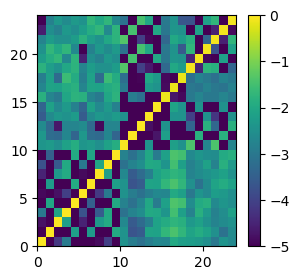

In [8]:
ShowProjections(FeGaTe, (0,0,0))
### the Wannier functions are close to the projectioin 
### --> almost diagonal matrix for r=(0,0,0)

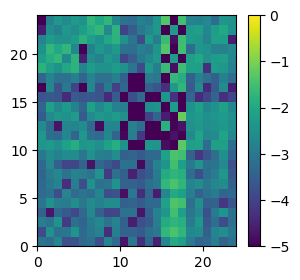

In [9]:
# nevertheless, contribution of other displacements is not zero
ShowProjections(FeGaTe, (1,0,0))

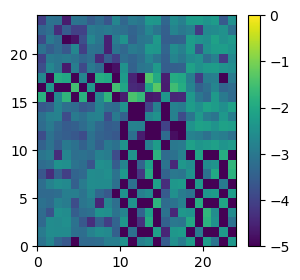

In [10]:
ShowProjections(FeGaTe, (0,1,0))

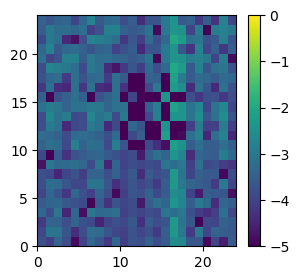

In [11]:
ShowProjections(FeGaTe, (2,0,0))

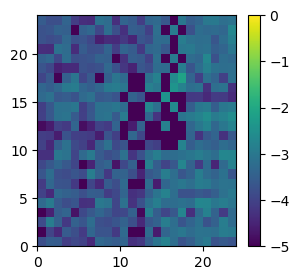

In [12]:
ShowProjections(FeGaTe, (2,2,0))

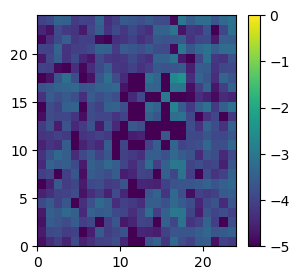

In [13]:
## it decreases when we go further away from (0,0,0) cell
ShowProjections(FeGaTe, (3,3,0))